# Baseline Target Model Evaluation
This notebook loads our tuned Random Forest classifier and evaluates it on the unseen 100-row Test Set.
We will calculate Accuracy, F1-Score, and plot the ROC curve. These metrics form the "Utility" side of our final Utility-vs-Privacy trade-off.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, roc_auc_score
import os

sns.set_theme(style="whitegrid")

# Load Test Data
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# Load Trained Model
model = joblib.load('../saved_models/target_model.pkl')
print("Model loaded successfully.")


Model loaded successfully.


Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.56      0.59        48
           1       0.63      0.69      0.66        52

    accuracy                           0.63       100
   macro avg       0.63      0.63      0.63       100
weighted avg       0.63      0.63      0.63       100



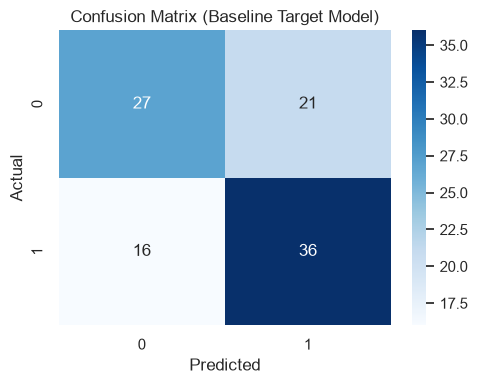

In [2]:
# 1. Classification Report & Confusion Matrix
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Baseline Target Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
os.makedirs('../results/figures', exist_ok=True)
plt.savefig('../results/figures/baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


Baseline AUC-ROC: 0.6997


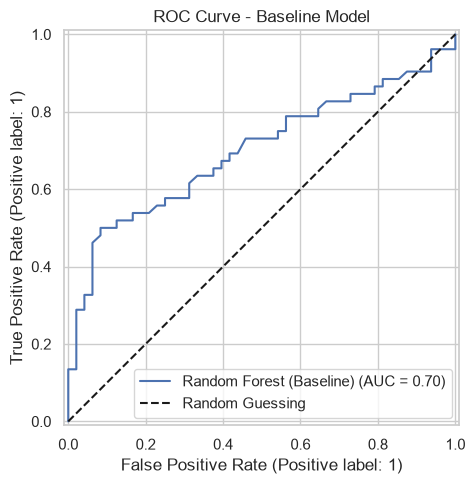

In [3]:
# 2. ROC Curve
# The ROC AUC score is highly resilient to class imbalance and is our primary utility metric.
y_proba = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_proba)
print(f"Baseline AUC-ROC: {auc_score:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name="Random Forest (Baseline)")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guessing")
plt.title("ROC Curve - Baseline Model")
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/baseline_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
